### Setup and imports

In [ ]:
import pandas as pd
import numpy as np
import rdkit
import ast
import matplotlib.pyplot as plt
#add future imports here

In [ ]:
df = pd.read_csv(r"data/IR spectroscopy data/SMILES_IR_Spectroscopy.csv", low_memory=False)

In [ ]:
def plot_graph(row):
    x_coords = row["x_coords"]
    y_coords = row["y_coords"]

    if isinstance(x_coords, str):
        x_coords = ast.literal_eval(x_coords)
    if isinstance(y_coords, str):
        y_coords = ast.literal_eval(y_coords)

    plt.figure(figsize=(10, 4))
    plt.plot(x_coords, y_coords, linewidth=1)
    plt.xlabel("1/cm")
    plt.ylabel("Absorbance")
    plt.title(row.get("smiles", "IR Spectrum"))
    plt.tight_layout()
    plt.show()
    return None

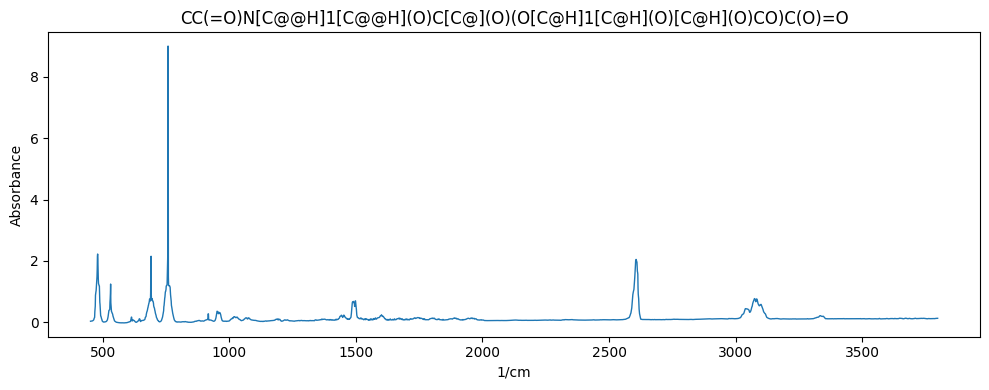

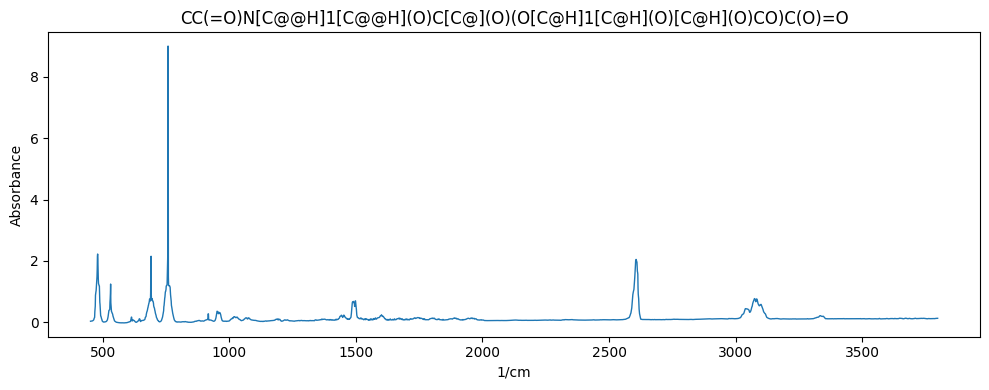

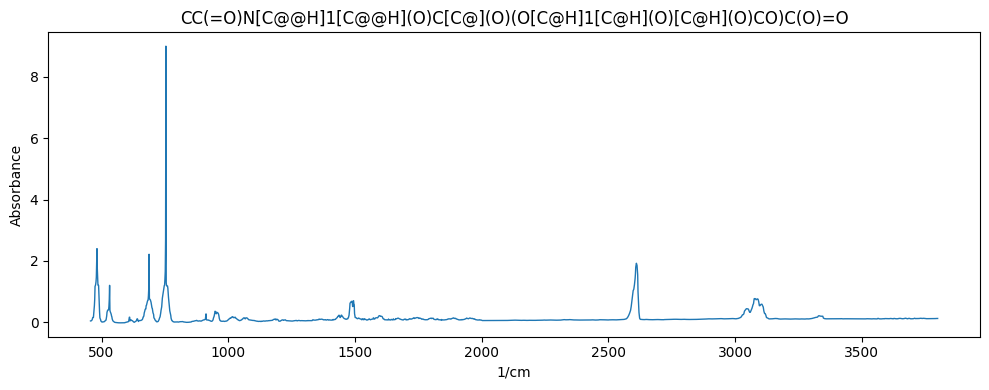

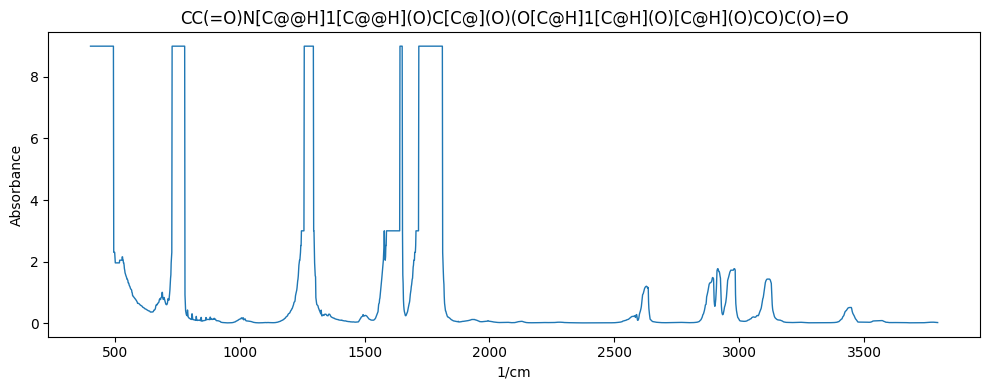

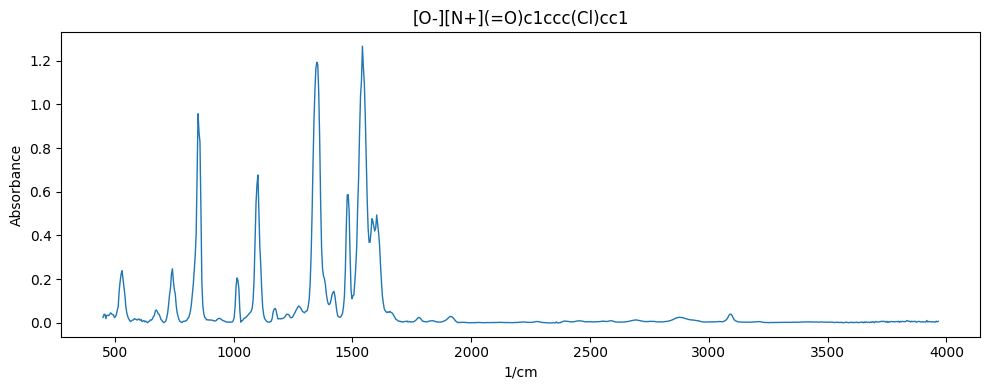

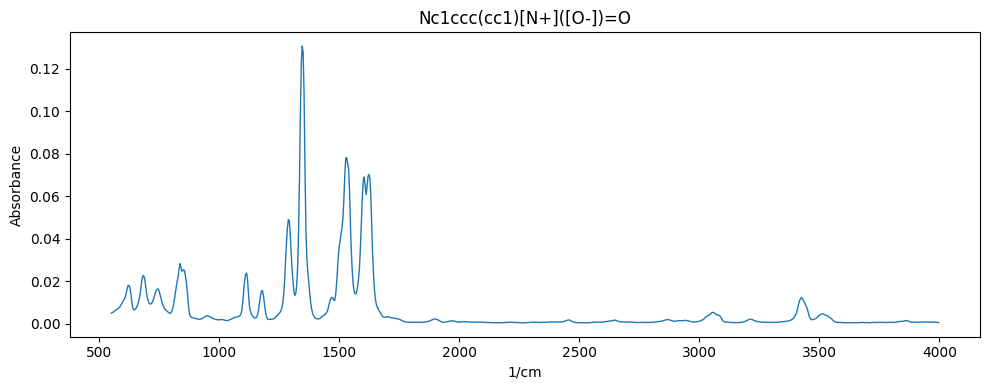

In [42]:
#test it
plot_graph(df.iloc[0])
for i in range(5):
    plot_graph(df.iloc[i])

## Normalization of data

### Standardize spectra through interpolating coordinate data to fixed grid 
* Using indiviail based normalizaiton and not group global normalization because:
  * experimental conditions may not have been consistant
  * the model learns scale artifacts (instrument, concentration) which makes it worse at generalization

In [36]:
# Perform row-wise min-max normalization on absorbance values.
def min_max_normalize_y_coords(y_coords):
    if isinstance(y_coords, str):
        y_coords = ast.literal_eval(y_coords)

    y_values = np.asarray(y_coords, dtype=float)
    if y_values.size == 0:
        return [], np.nan, np.nan, np.nan

    y_min = float(np.min(y_values))
    y_max = float(np.max(y_values))
    y_range = y_max - y_min

    if y_range == 0:
        normalized_y = np.zeros_like(y_values, dtype=float)
    else:
        normalized_y = (y_values - y_min) / y_range

    return normalized_y.tolist(), y_min, y_max, y_range


normalized_y_df = df.copy()
y_normalization_metadata = normalized_y_df["y_coords"].apply(min_max_normalize_y_coords)

normalized_y_df["y_coords"] = y_normalization_metadata.apply(lambda values: values[0]).astype(object)
normalized_y_df["y_min_before_minmax"] = y_normalization_metadata.apply(lambda values: values[1])
normalized_y_df["y_max_before_minmax"] = y_normalization_metadata.apply(lambda values: values[2])
normalized_y_df["y_range_before_minmax"] = y_normalization_metadata.apply(lambda values: values[3])
normalized_y_df["y_normalization"] = "row_min_max_0_1"


====regular0=====


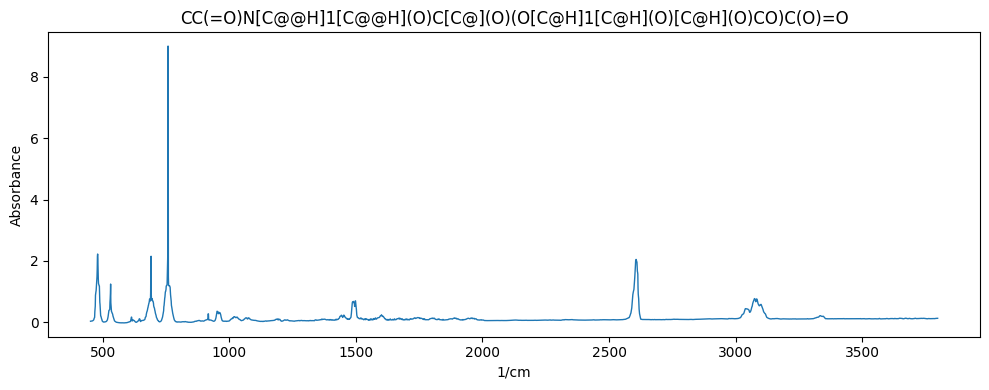

====normalized0=====


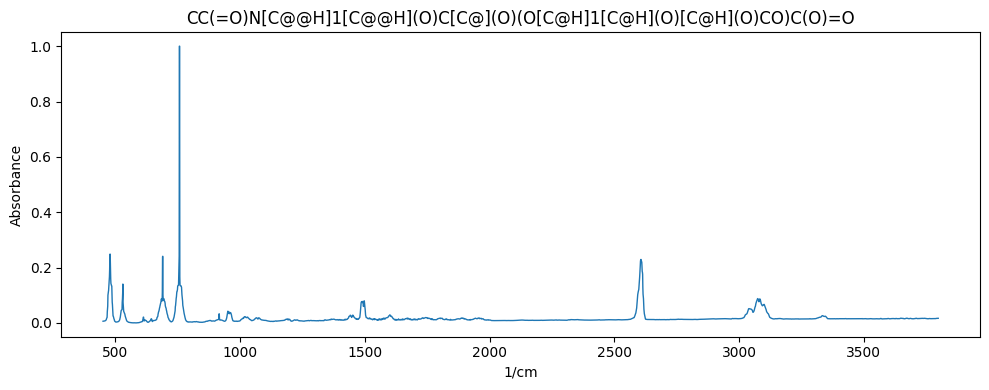

====regular1=====


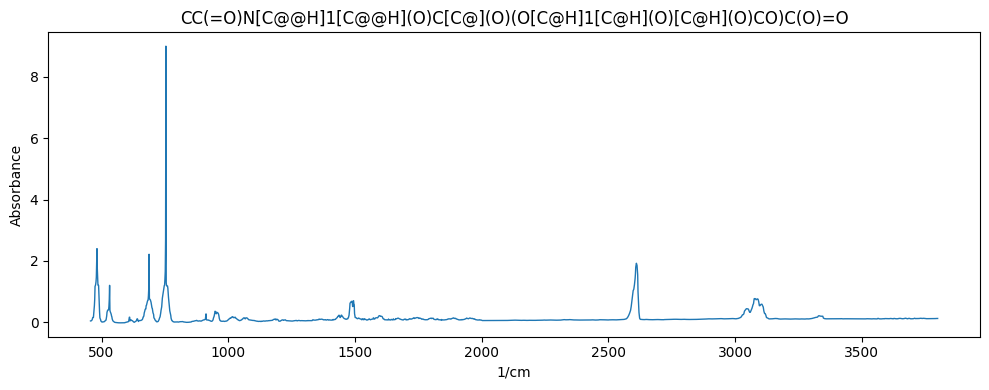

====normalized1=====


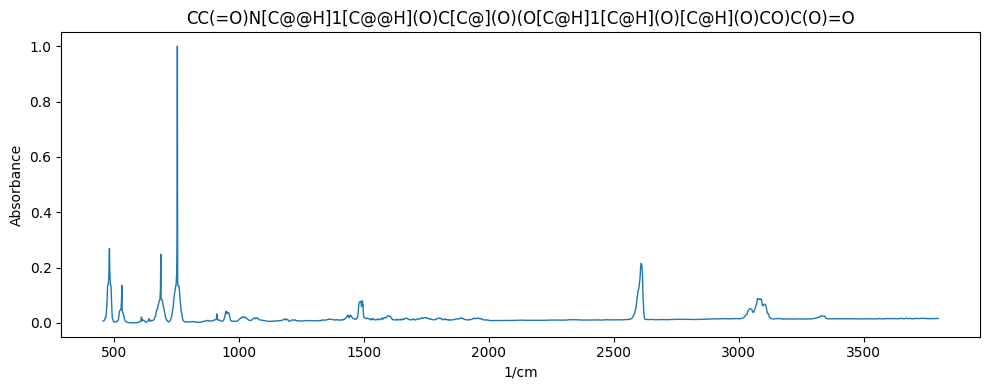

====regular2=====


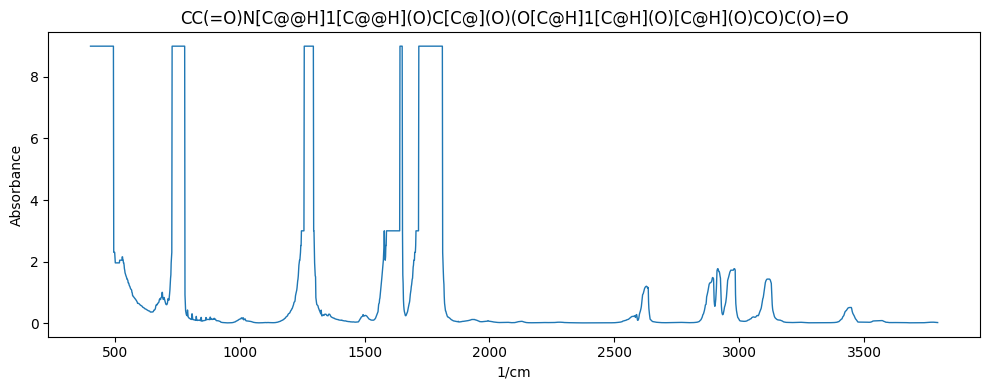

====normalized2=====


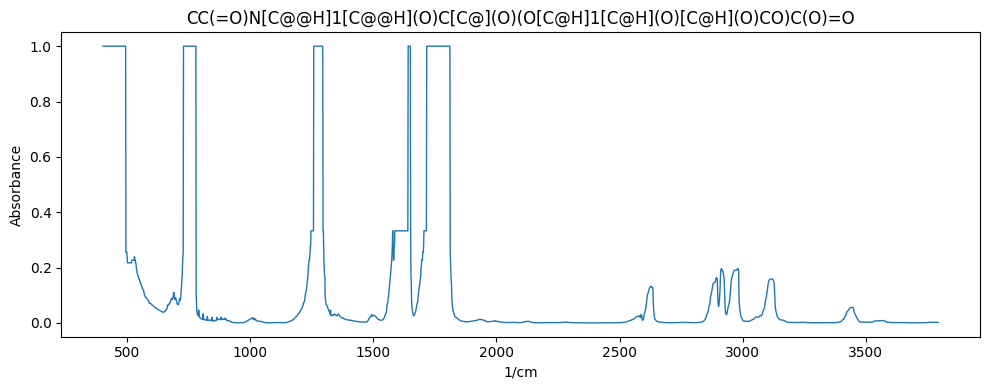

====regular3=====


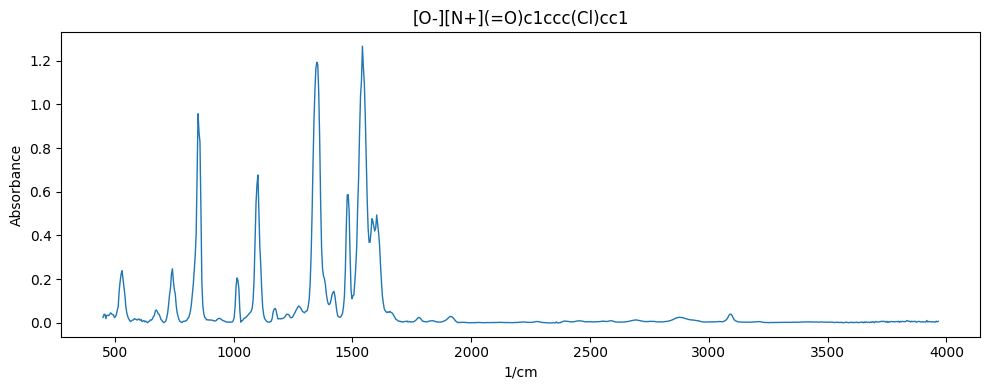

====normalized3=====


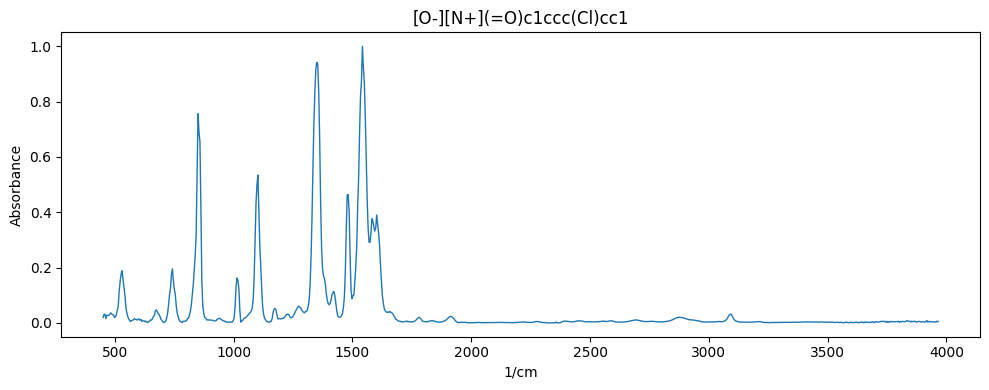

====regular4=====


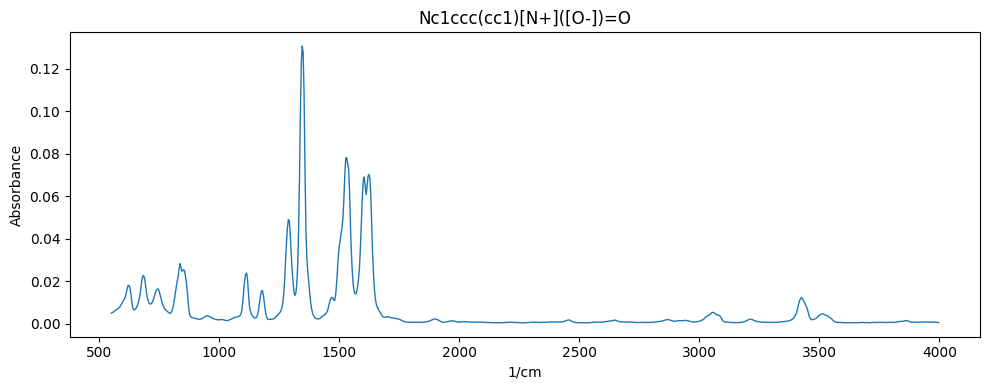

====normalized4=====


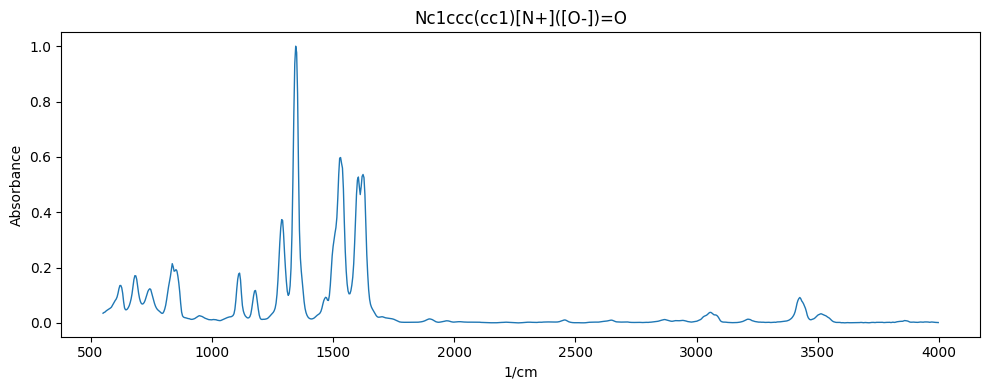

In [37]:
#test it
for i in range(5):
    print(f'====regular{i}=====')
    plot_graph(df.iloc[i])
    print(f'====normalized{i}=====')
    plot_graph(normalized_y_df.iloc[i])
    print(f'===================')

## Labeling

### Canonicallize smiles 
* learn more at 
  * https://luis-vollmers.medium.com/tutorial-to-smiles-and-canonical-smiles-explained-with-examples-fbc8a46ca29f

In [41]:
#Smiles canonicalization implementation
from rdkit import Chem

def canonicalize_smiles(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None
        return Chem.MolToSmiles(mol)
    except:
        return None

normalized_y_df['canonical_smiles'] = normalized_y_df['smiles'].apply(canonicalize_smiles)
canonicalized_smiles_df = normalized_y_df
print(f"Successfully canonicalized: {canonicalized_smiles_df['canonical_smiles'].notna().sum()} our of {len(canonicalized_smiles_df)}")
canonicalized_smiles_df.head()

[20:56:00] WARNING: not removing hydrogen atom without neighbors
[20:56:00] WARNING: not removing hydrogen atom without neighbors
[20:56:00] WARNING: not removing hydrogen atom without neighbors
[20:56:00] WARNING: not removing hydrogen atom without neighbors
[20:56:00] WARNING: not removing hydrogen atom without neighbors
[20:56:00] WARNING: not removing hydrogen atom without neighbors
[20:56:00] WARNING: not removing hydrogen atom without neighbors
[20:56:00] WARNING: not removing hydrogen atom without neighbors
[20:56:00] WARNING: not removing hydrogen atom without neighbors
[20:56:00] WARNING: not removing hydrogen atom without neighbors
[20:56:00] WARNING: not removing hydrogen atom without neighbors
[20:56:00] WARNING: not removing hydrogen atom without neighbors
[20:56:00] WARNING: not removing hydrogen atom without neighbors
[20:56:00] WARNING: not removing hydrogen atom without neighbors
[20:56:01] WARNING: not removing hydrogen atom without neighbors
[20:56:01] WARNING: not r

Successfully canonicalized: 8994 our of 8994


,filename,smiles,origin_xunits,origin_yunits,x_coords,y_coords,canonical_smiles,y_min_before_minmax,y_max_before_minmax,y_range_before_minmax,y_normalization
0,B6010491_IR_0.jdx,CC(=O)N[C@@H]1[C@@H](O)C[C@](O)(O[C@H]1[C@H](O...,1/CM,TRANSMITTANCE,"[451.282, 452.1367016, 452.9914032, 453.846104...","[0.005966423694845339, 0.006069819205967292, 0...",CC(=O)N[C@H]1[C@H]([C@H](O)[C@H](O)CO)O[C@](O)...,-0.023252,9.00000,9.023252,row_min_max_0_1
1,B6010491_IR_1.jdx,CC(=O)N[C@@H]1[C@@H](O)C[C@](O)(O[C@H]1[C@H](O...,1/CM,TRANSMITTANCE,"[456.596, 457.8726036, 459.1492072, 460.425810...","[0.007070857317209818, 0.0071767600856635395, ...",CC(=O)N[C@H]1[C@H]([C@H](O)[C@H](O)CO)O[C@](O)...,-0.022841,9.00000,9.022841,row_min_max_0_1
2,B6010497_IR_0.jdx,CC(=O)N[C@@H]1[C@@H](O)C[C@](O)(O[C@H]1[C@H](O...,1/CM,TRANSMITTANCE,"[403.266, 404.5222826, 405.7785652, 407.034847...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",CC(=O)N[C@H]1[C@H]([C@H](O)[C@H](O)CO)O[C@](O)...,0.008774,9.00000,8.991226,row_min_max_0_1
3,C100005_IR_0.jdx,[O-][N+](=O)c1ccc(Cl)cc1,1/CM,ABSORBANCE,"[450.0, 454.0, 458.0, 462.0, 466.0, 470.0, 474...","[0.019799999999999998, 0.030599999999999995, 0...",O=[N+]([O-])c1ccc(Cl)cc1,0.000000,1.26587,1.265870,row_min_max_0_1
4,C100016_IR_0.jdx,Nc1ccc(cc1)[N+]([O-])=O,1/CM,ABSORBANCE,"[551.688, 555.546, 559.404, 563.262, 567.12, 5...","[0.035009700594939096, 0.03739068589273892, 0....",Nc1ccc([N+](=O)[O-])cc1,0.000492,0.13069,0.130198,row_min_max_0_1


### Create Labels 
* using martini 3 mapping algorithm to label compounds from smiles
* refer to paper 

In [45]:
#load the labelled data 
labelled_df  = pd.read_csv("data/IR spectroscopy data/Labelled_SMILES_IR_Spectroscopy.csv")

## Data Splitting

## Baseline Modeling

### Compare Against Classical Baseline

## Main Model

### Build CNN with Multi-Task Outputs
* hyper parameters and justification
  * using cross entropy loss function for multi classification
  * in channels: spectroscopy (x,y) pair coordinate values, 

### Train the Model

## Evaluation
* for results section

### Evaluate Functional Group Prediction (F1, Precision, Recall)

### Evaluate Retrieval Performance (Top-K Accuracy, MRR)

### Calibration and Confidence Analysis

## Deployment Design

### Functional Group Probability Outputs

### Top-K SMILES Candidate Retrieval

### Confidence and Uncertainty Display